In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path("/common/ganesanv/tlab/src/datasets").resolve()))

from adni.dataset import (
    ADNIClassificationDataset,
    IMAGENET_MEAN,
    IMAGENET_STD,
    LABEL_TO_DIAGNOSIS,
)

ROOT = Path("/common/ganesanv/tlab/data/ADNI")
# Mid-volume band keeps one representative slice per scan without indexing every z.
ds = ADNIClassificationDataset(
    ROOT,
    z_min=0.49,
    z_max=0.51,
    augment=False,
    image_size=224,
    volume_cache_size=2,
)
print(f"scans/slices indexed: {len(ds)}")
print(
    f"example: patient={ds.get_patient_id(0)}, image={ds.get_image_id(0)}, "
    f"label={LABEL_TO_DIAGNOSIS[ds.get_target(0)]}"
)

scans/slices indexed: 11504
example: patient=023_S_0058, image=I31008, label=CN


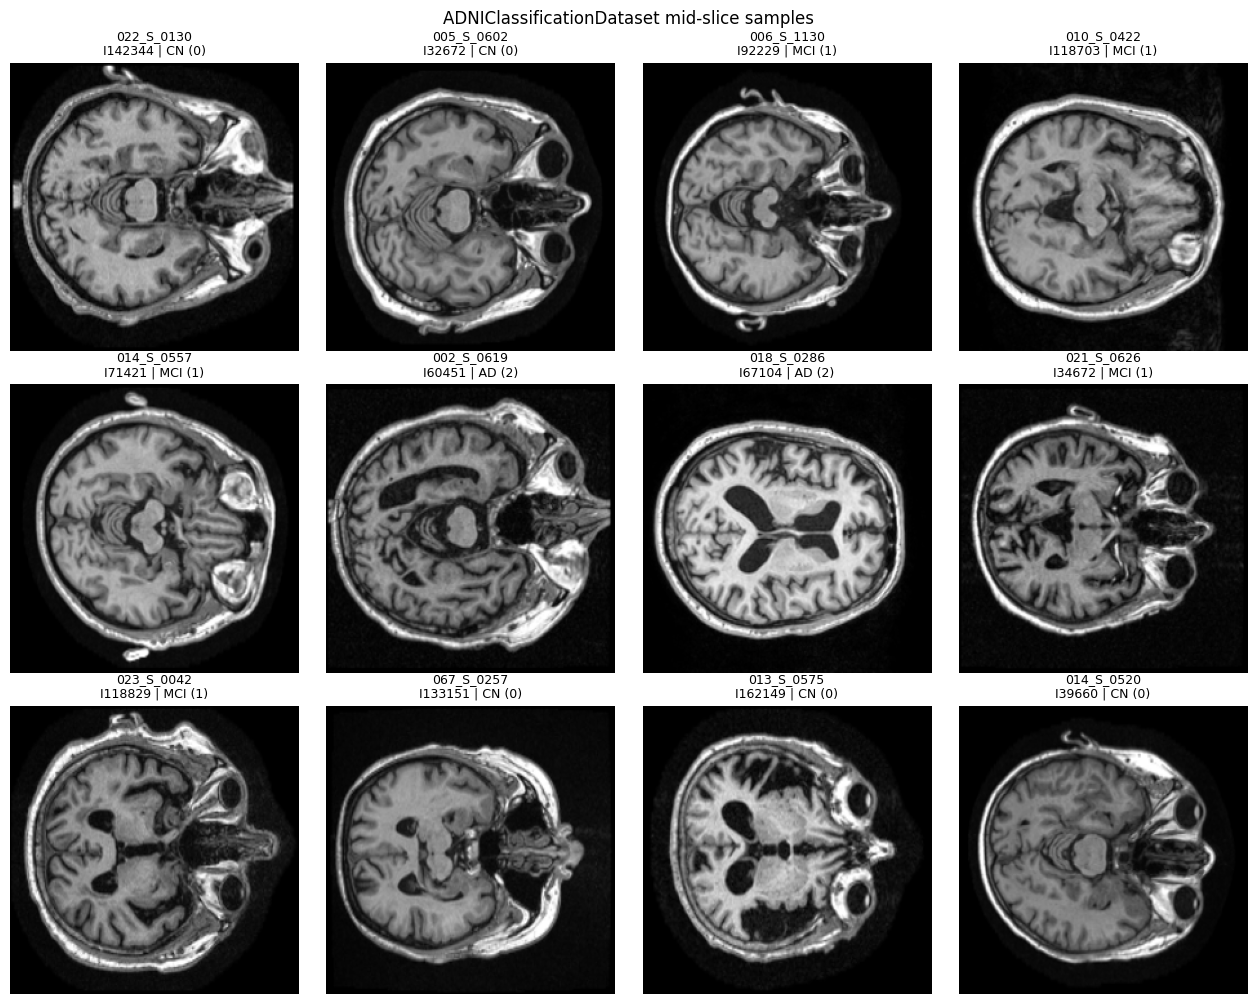

In [10]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = (tensor.detach().cpu() * std + mean).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


rng = np.random.default_rng(0)
n_show = 12
indices = rng.choice(len(ds), size=min(n_show, len(ds)), replace=False)

ncols = 4
nrows = int(np.ceil(len(indices) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, idx in zip(axes, indices):
    image, label = ds[int(idx)]
    patient_id = ds.get_patient_id(int(idx))
    image_id = ds.get_image_id(int(idx))
    diagnosis = LABEL_TO_DIAGNOSIS[int(label)]
    ax.imshow(denormalize(image))
    ax.set_title(f"{patient_id}\n{image_id} | {diagnosis} ({int(label)})", fontsize=9)
    ax.axis("off")

for ax in axes[len(indices):]:
    ax.axis("off")

fig.suptitle("ADNIClassificationDataset mid-slice samples", fontsize=12)
fig.tight_layout()
plt.show()